# Detecting Topic Merges and Splits in Dynamic Political Conversations

Cláudia Oliveira 

Supervisor - Prof. Dr. Álvaro Figueira

Faculty of Science, University of Porto

Import packages

In [ ]:
import pandas as pd
import re
import string
import emoji
import spacy
from nltk.corpus import stopwords
import nltk
#nltk.download('stopwords')
import spacy
#spacy.cli.download("en_core_web_sm")
import sys
from functions import *
from collections import Counter
nlp_ner = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))
from datetime import timedelta
from multiprocessing import Pool, cpu_count
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from multiprocessing import Pool, cpu_count
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.dates as mdates
import ast
import os
os.chdir("../..")

### Part 1 - Process Data

Removing the tweets that aren't in english and concatenate the text from the tweet with the hashtags and urls and clean 

In [2]:
tweets = pd.read_csv("datasets/tweets.csv", encoding="utf-8", low_memory=False)

tweets = tweets[tweets['language'] == 'en'].copy()

tweets["text_original"] = tweets["text"]

tweets['text_combined'] = parallel_apply(tweets, clean_tweet_row)

Eliminate empty lanes

In [3]:
tweets = tweets[tweets['text_combined'].str.strip() != ""].copy()

In [4]:
tweets['text_combined'].head(10)

0                                   tweet private like
1                         let go repyvetteclarke unity
2                                 illegal realtomhoman
3    clear charlie kirk man believe civil right act...
4    scourge gun violence political violence must e...
5    go assume try reply burp tweet ether instead s...
6    nyer know andrew cuomo back trump orbit lose p...
7    chriscuomo deepfake dude please use critical t...
8    force famine million people gaza include one f...
9                                   let go votejgr get
Name: text_combined, dtype: object

Check which are the most common used entities so we can try to normalize them 

In [5]:
all_entities = []

for doc in nlp_ner.pipe(tweets['text_combined'], batch_size=500, n_process=4):
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "ORG"]:
            all_entities.append(ent.text)

entity_counts = Counter(all_entities)
top_entities = entity_counts.most_common(200)

for ent, count in top_entities:
    print(f"{ent}: {count}")

congress: 20121
senate: 11582
medicaid: 4027
donald trump: 3939
gop: 3703
medicare: 3386
fema: 3050
fbi: 2214
house: 2199
white house: 2049
putin: 1892
supreme court: 1749
irs: 1746
joe biden: 1504
united states: 1359
epa: 1283
charlie kirk: 1125
laken riley: 1108
cnn: 1086
un: 937
sec: 885
biden harris: 883
kamala harris: 832
ccp: 754
pentagon: 733
hegseth: 720
nih: 712
nato: 671
trump administration: 662
johnson: 655
god: 635
biden harris administration: 603
capitol: 572
nasa: 568
capitol hill: 557
pbs: 549
jimmy carter: 513
fda: 504
carter: 499
trump agenda: 488
hamadeh: 475
hezbollah: 456
navy: 448
fed: 394
treasury: 376
ag: 374
trump america: 371
msnbc: 356
reagan: 356
ga: 341
elon musk: 331
biden: 297
trump: 296
kim: 296
donald: 293
charlie: 272
lincoln: 270
mike johnson: 266
kennedy: 257
npr: 248
fcc: 241
cia: 240
rosh hashanah: 234
nevadan: 233
cnbc: 232
gutte: 231
abc: 226
united states america: 224
leo xiv: 221
joe biden kamala harris: 220
taliban: 218
trump elon: 214
jesus: 

In [6]:
entity_dict = {
    # Those who have to change
    "capitol hill": "capitol",
    "fbi": "federal bureau of investigation",
    "cia": "central intelligence agency",
    "epa": "environmental protection agency",
    "fda": "food and drug administration",
    "fema": "federal emergency management agency",
    "fcc": "federal communications commission",
    "irs": "internal revenue service",
    "sec": "securities and exchange commission",
    "fed": "federal reserve",
    "hud": "department of housing and urban development",
    "cdc": "centers for disease control and prevention",
    "nih": "national institutes of health",
    "medicaid medicare": "medicare and medicaid",
    "medicare medicaid": "medicare and medicaid",
    "aca": "affordable care act",
    "ndaa": "national defense authorization act",
    "un": "united nations",
    "biden": "joe biden",
    "joe": "joe biden",
    "biden harris": "joe biden kamala harris",
    "harris": "kamala harris",
    "trump": "donald trump",
    "trumps": "donald trump",
    "putin": "vladimir putin",
    "reagan": "ronald reagan",
    "carter": "jimmy carter",
    "rubio": "marco rubio",
    "mike": "mike johnson",
    "charlie": "charlie kirk",
    "petehegseth": "pete hegseth",
    "johnson": "mike johnson",
    "kennedy": "john f kennedy", 
    "npr pbs": "npr and pbs",
    "wsj wsj": "wall street journal",
    "house news documentsingle": "house news",
    "morningsmaria": "mornings with maria",
    "ccp": "chinese communist party",
    "netanyahu": "benjamin netanyahu",
    "zelensky": "volodymyr zelensky",
    "housedemocrat": "democratic party",
    "gop": "republican party",
    "united state": "united states of america",
    "united states": "united states of america",
    
    # Those remaining the same
    "congress": "congress",
    "senate": "senate",
    "medicaid": "medicaid",
    "house": "house",
    "hamas": "hamas",
    "white house": "white house",
    "healthcare": "healthcare",
    "capitol": "capitol",
    "laken riley act": "laken riley act",
    "laken riley": "laken riley",
    "elon musk": "elon musk",
    "pope francis": "pope francis",
    "harvard": "harvard",
    "matt": "matt",
    "linda mcmahon": "linda mcmahon",
    "bill house": "bill house",
    "cbs": "cbs",
    "town hall": "town hall",
    "jeffrey epstein": "jeffrey epstein",
    "nj": "nj",
    "chuck schumer": "chuck schumer",
    "miller": "miller",
    "ec": "ec",
    "arkansa": "arkansa",
    "trump agenda": "trump agenda",
    "chris": "chris",
    "nebraskan": "nebraskan",
    "trump house": "trump house",
    "big news": "big news",
    "army": "army",
    "senate news": "senate news",
    "senate news press": "senate news press",
    "please join": "please join",
    "kash patel": "kash patel",
    "kim": "kim",
    "donald j": "donald j",
    "hurricane milton": "hurricane milton",
    "buff": "buff",
    "lincoln": "lincoln",
    "rosh hashanah": "rosh hashanah",
    "taylor": "taylor",
    "ga": "ga",
    "abc": "abc",
    "taliban": "taliban",
    "coast guard": "coast guard",
    "marine corps": "marine corps",
    "justice department": "justice department",
    "american energy": "american energy",
    "fox news": "fox news",
    "paul": "paul",
    "clinton": "clinton",
    "army corps": "army corps",
    "dreamer": "dreamer",
    "kremlin": "kremlin",
    "gutte medicaid": "gutte medicaid",
    "gerry connolly": "gerry connolly",
    "rick scott": "rick scott",
    "social security": "social security",
    "proud join": "proud join",
    "jd vance": "jd vance",
    "austin": "austin",
    "melissa hortman": "melissa hortman",
    "solidarity": "solidarity",
    "maxwell": "maxwell",
    "george washington": "george washington",
    "raul gonzalez": "raul gonzalez",
    "john hoffman": "john hoffman",
    "john": "john",
    "gold star": "gold star",
    "tom homan": "tom homan",
    "wwii": "wwii",
    "mexico canada": "mexico canada",
    "media center press": "media center press",
    "icymi join": "icymi join",
    "pell": "pell",
    "social security administration": "social security administration",
    "amtrak": "amtrak",
    "bipartisan bill": "bipartisan bill",
    "abbey gate": "abbey gate",
    "kilmar": "kilmar",
    "national police week": "national police week",
    "david": "david",
    "williams": "williams",
    "ivf": "ivf",
    "mar lago": "mar lago",
    "catholic church": "catholic church",
    "hawley": "hawley",
    "countdowntosrd countdowntosrd": "countdowntosrd countdowntosrd",
    "dr martin luther king jr": "dr martin luther king jr",
    "michael": "michael",
    "thompson": "thompson",
    "smithsonian": "smithsonian",
    "davis": "davis",
    "markup": "markup",
    "jesus": "jesus",
    "al": "al",
    "chag": "chag",
    "house armed services committee": "house armed services committee",
    "george floyd": "george floyd",
    "senate judiciary committee": "senate judiciary committee",
    "warren": "warren",
    "trump administration": "trump administration",
    "medicare": "medicare",
    "pentagon": "pentagon",
    "nasa": "nasa",
    "nato": "nato",
    "hamadeh": "hamadeh",
    "hezbollah": "hezbollah",
    "honor join": "honor join",
    "navy": "navy",
    "tim": "tim",
    "nebraska": "nebraska",
    "cnbc": "cnbc",
    "john lewis": "john lewis",
    "secrollin": "secrollin",
    "intel": "intel",
    "senate newsroom": "senate newsroom",
    "katie britt": "katie britt",
    "leo xiv": "leo xiv",
    "mike johnson": "mike johnson",
    "biden administration": "biden administration",
    "joe biden kamala harris": "joe biden kamala harris",
    "bill senate": "bill senate",
    "media press": "media press",
    "gutte": "gutte",
    "jimmy kimmel": "jimmy kimmel",
    "joe biden": "joe biden",
    "god": "god",
    "npr": "npr",
    "kamala harris": "kamala harris",
    "pete hegseth": "pete hegseth",
    "biden harris administration": "biden harris administration",
    "chinese communist party": "chinese communist party",
    "vladimir putin": "vladimir putin",
    "kilmar abrego garcia": "kilmar abrego garcia",
    "ronald reagan": "ronald reagan",
    "social security medicare": "social security medicare",
    "marco rubio": "marco rubio",
    "repjeffrie": "repjeffrie",
    "jack smith": "jack smith",
    "ford": "ford",
    "job corps": "job corps",
    "god bless america": "god bless america",
    "supreme court": "supreme court",
    "cnn": "cnn", 
    "treasury": "treasury",
    "msnbc": "msnbc",
    "pbs": "pbs",
    "mahmoud khalil": "mahmoud khalil"
}

In [7]:
print(len(entity_dict))

193


There are 193 because I only chose people and organizations

In [9]:
tweets = tweets.reset_index(drop=True)
tweets["doc_id"] = tweets.index

In [10]:
tweets['text_normalized'] = tweets['text_combined'].apply(
    lambda x: normalize_entities(x, entity_dict, list(entity_dict.keys()))
)

In [11]:
tweets['text_normalized'].head(10)

0                                   tweet private like
1                         let go repyvetteclarke unity
2                                 illegal realtomhoman
3    clear charlie kirk kirk man believe civil righ...
4    scourge gun violence political violence must e...
5    go assume try reply burp tweet ether instead s...
6    nyer know andrew cuomo back donald trump orbit...
7    chriscuomo deepfake dude please use critical t...
8    force famine million people gaza include one f...
9                                   let go votejgr get
Name: text_normalized, dtype: object

Top Features using TF-IDF

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)

tfidf_matrix = vectorizer.fit_transform(tweets['text_normalized'])

tfidf_scores = tfidf_matrix.mean(axis=0).A1
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({'term': terms, 'score': tfidf_scores})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False)

top50 = tfidf_df.head(50)
print(top50)

             term     score
1344       donald  0.024746
4609        trump  0.022696
4941         work  0.016092
3417    president  0.015534
2687         make  0.014162
180      american  0.013987
1673       family  0.013796
445          bill  0.013353
3266       people  0.012593
863     community  0.012452
1104          day  0.012410
4510        today  0.012344
178       america  0.012252
4450        thank  0.012024
2152        house  0.011661
3090          one  0.011362
4978         year  0.011184
1899          get  0.010909
2953         need  0.010741
1069          cut  0.010659
1951        great  0.010490
48            act  0.010456
4335      support  0.010368
1699      federal  0.010097
1719        fight  0.010068
181     americans  0.009834
4397          tax  0.009656
3493      protect  0.009393
619          care  0.009374
2970          new  0.009358
2069         help  0.009319
2046       health  0.009187
2467         keep  0.009100
4499         time  0.009043
912      congress  0

Word Cloud

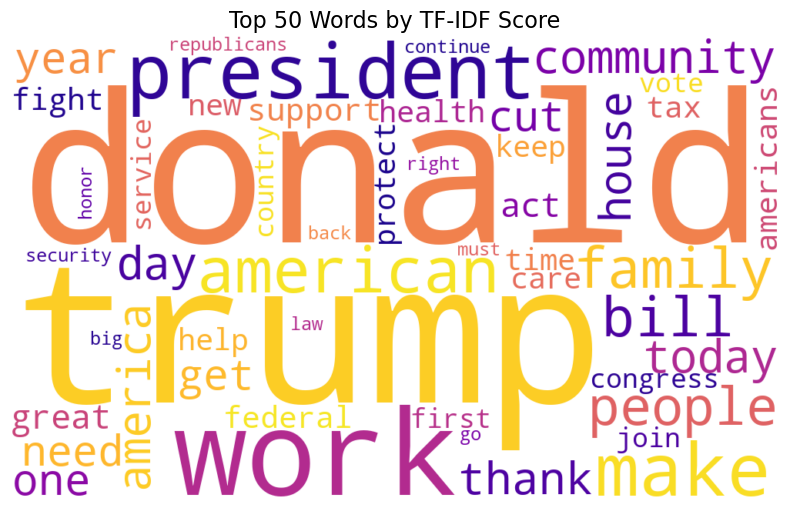

In [13]:
word_scores = dict(zip(top50['term'], top50['score']))

wc = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='plasma'
).generate_from_frequencies(word_scores)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Top 50 Words by TF-IDF Score", fontsize=16)
plt.show()

Tokenizing

In [14]:
tweets["tokens"] = tweets["text_normalized"].apply(spacy_tokenize)
tweets["tokens"].head(5)

0                               [tweet, private, like]
1                    [let, go, repyvetteclarke, unity]
2                              [illegal, realtomhoman]
3    [clear, charlie, kirk, kirk, man, believe, civ...
4    [scourge, gun, violence, political, violence, ...
Name: tokens, dtype: object

Collumn with preprocess for Model Top2Vec

In [15]:
tweets["preprocess_top2vec"] = tweets["text"].apply(preprocess_for_top2vec)

tweets["preprocess_top2vec"].head(10)

0             Why are you tweeting your private likes?
1                                    Let s go ! UNITY.
2                                Who s the illegal now
3    We should be clear about who Charlie Kirk was:...
4    The scourge of gun violence and political viol...
5    I m going to assume you were trying to reply t...
6    NYers knew Andrew Cuomo was backed by Trump s ...
7    This is a deepfake dude. Please use your criti...
8    The forced famine of more than 2 million peopl...
9                                Let s GO ! We got you
Name: preprocess_top2vec, dtype: object

Saving the cleaned dataset

In [17]:
tweets.to_csv(
    "datasets/cleanedtweets2.csv",
    index=False,
    columns=[
        "doc_id",
        "created_at",
        "text_original",
        "text_combined",
        "text_normalized",
        "tokens"
    ]
)

### Part 2 - Modelling

In [2]:
tweets = pd.read_csv("datasets/cleanedtweets.csv", encoding="utf-8", low_memory=False)

Only keeping the interesting columns for the objective of this work

In [3]:
tweets = tweets[['created_at', 'tokens']].copy()
tweets['created_at'] = pd.to_datetime(tweets['created_at'])
tweets = tweets.sort_values('created_at')
tweets['tokens'] = tweets['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [4]:
df_results_lda = run_dynamic_pipeline(tweets, model_type='lda')

In [5]:
df_results_lda.head(5)

,start_date,end_date,num_docs,cv,npmi,umass,diversity,tq,topics
0,2024-09-26,2024-10-03,5653,0.574456,0.080781,-3.913306,0.982222,0.564244,[year | jimmy | rosh | celebrate | hashanah | ...
1,2024-09-29,2024-10-06,5526,0.630287,0.105561,-4.128082,0.977778,0.616281,[year | new | celebrate | rosh | hashanah | wi...
2,2024-10-02,2024-10-09,5576,0.671434,0.118194,-3.378407,0.971111,0.652037,[gun | utm | chinese | landfall | walz | share...
3,2024-10-05,2024-10-12,5518,0.677848,0.135464,-3.282065,0.973333,0.659772,[daca | court | family | dreamer | must | case...
4,2024-10-08,2024-10-15,5059,0.496697,0.029750,-5.262563,0.973333,0.483452,[community | indigenous | day | people | happy...


In [9]:
df_results_nmf = run_dynamic_pipeline(tweets, model_type='nmf')

In [10]:
df_results_nmf.head(5)

,start_date,end_date,num_docs,cv,npmi,umass,diversity,tq,topics
0,2024-09-26,2024-10-03,5653,0.785397,0.245234,-2.101864,0.975556,0.766198,[joe | biden | kamala | harris | administratio...
1,2024-09-29,2024-10-06,5526,0.810929,0.269020,-1.967130,0.986667,0.800117,[kamala | biden | joe | harris | administratio...
2,2024-10-02,2024-10-09,5576,0.815479,0.258563,-1.645910,0.973333,0.793733,[hostage | hamas | one | innocent | year | peo...
3,2024-10-05,2024-10-12,5518,0.768088,0.249013,-2.192204,0.980000,0.752726,[israel | hostage | hamas | terrorist | attack...
4,2024-10-08,2024-10-15,5059,0.776305,0.254808,-2.070347,0.975556,0.757328,[work | community | great | make | thank | fam...


In [ ]:
df_results_lda.to_csv("datasets/ldaresults.csv", index=False)
df_results_nmf.to_csv("datasets/nmfresults.csv", index=False)